In [1]:
pip install pandas openpyxl matplotlib

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
df = pd.read_excel(
    r"C:\Users\jeme0\Downloads\Traffic_Accident_Dataset_2000Rows.xlsx"
)

In [7]:
df.head()

,Accident_ID,Weather,Road_Condition,Time_of_Day,Severity,Vehicles_Involved,Injuries,City
0,1,Clear,Dry,Evening,2,2,2,New York
1,2,Cloudy,Dry,Night,1,1,1,Los Angeles
2,3,Rain,Dry,Afternoon,5,4,3,Houston
3,4,Cloudy,Under Construction,Morning,2,6,6,Chicago
4,5,Fog,Wet,Afternoon,3,1,1,Houston


In [9]:
df.tail()

,Accident_ID,Weather,Road_Condition,Time_of_Day,Severity,Vehicles_Involved,Injuries,City
1995,1996,Snow,Under Construction,Afternoon,4,3,0,Los Angeles
1996,1997,Rain,Under Construction,Evening,3,1,5,Houston
1997,1998,Snow,Under Construction,Afternoon,2,5,8,Houston
1998,1999,Fog,Dry,Morning,2,2,5,Houston
1999,2000,Cloudy,Icy,Morning,4,6,7,Los Angeles


In [11]:
df.shape

(2000, 8)

In [13]:
df.columns

Index(['Accident_ID', 'Weather', 'Road_Condition', 'Time_of_Day', 'Severity',
       'Vehicles_Involved', 'Injuries', 'City'],
      dtype='object')

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Accident_ID        2000 non-null   int64 
 1   Weather            2000 non-null   object
 2   Road_Condition     2000 non-null   object
 3   Time_of_Day        2000 non-null   object
 4   Severity           2000 non-null   int64 
 5   Vehicles_Involved  2000 non-null   int64 
 6   Injuries           2000 non-null   int64 
 7   City               2000 non-null   object
dtypes: int64(4), object(4)
memory usage: 125.1+ KB


In [17]:
df.describe()

,Accident_ID,Severity,Vehicles_Involved,Injuries
count,2000.000000,2000.000000,2000.00000,2000.000000
mean,1000.500000,3.016500,3.49350,5.107500
std,577.494589,1.409688,1.73651,3.189362
min,1.000000,1.000000,1.00000,0.000000
25%,500.750000,2.000000,2.00000,2.000000
50%,1000.500000,3.000000,3.00000,5.000000
75%,1500.250000,4.000000,5.00000,8.000000
max,2000.000000,5.000000,6.00000,10.000000


In [19]:
df.isnull().sum()

Accident_ID          0
Weather              0
Road_Condition       0
Time_of_Day          0
Severity             0
Vehicles_Involved    0
Injuries             0
City                 0
dtype: int64

In [21]:
df = df.drop_duplicates()

In [23]:
df['Weather'].value_counts()

Weather
Snow      419
Rain      412
Cloudy    404
Fog       390
Clear     375
Name: count, dtype: int64

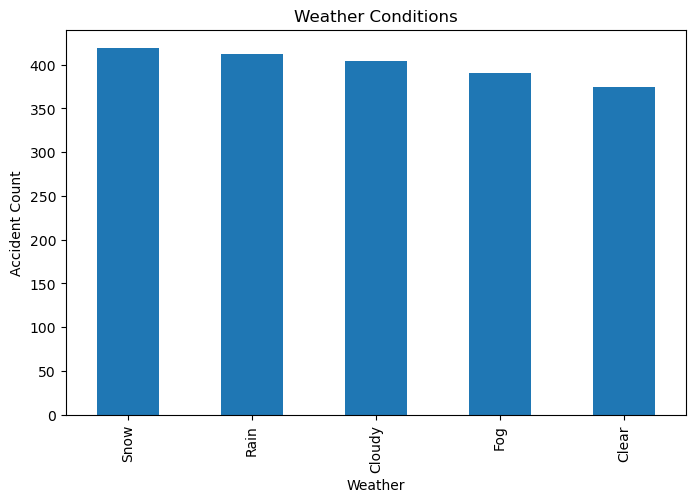

In [25]:
plt.figure(figsize=(8,5))

df['Weather'].value_counts().plot(
    kind='bar'
)

plt.title('Weather Conditions')
plt.xlabel('Weather')
plt.ylabel('Accident Count')

plt.show()

In [27]:
df['Road_Condition'].value_counts()

Road_Condition
Icy                   511
Under Construction    504
Wet                   500
Dry                   485
Name: count, dtype: int64

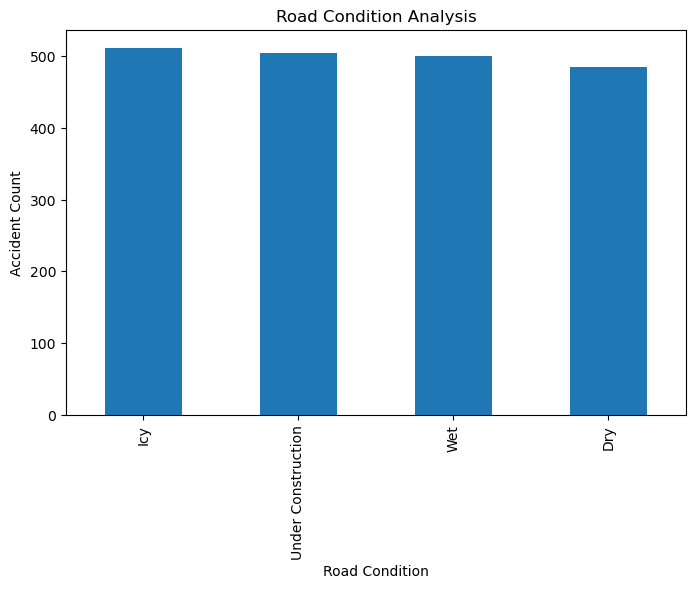

In [29]:
plt.figure(figsize=(8,5))

df['Road_Condition'].value_counts().plot(
    kind='bar'
)

plt.title('Road Condition Analysis')
plt.xlabel('Road Condition')
plt.ylabel('Accident Count')

plt.show()

In [31]:
df['Time_of_Day'].value_counts()

Time_of_Day
Morning      520
Night        504
Evening      498
Afternoon    478
Name: count, dtype: int64

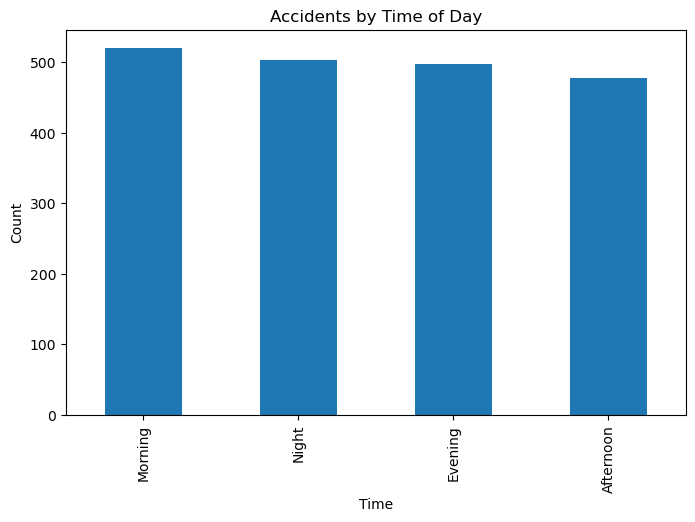

In [33]:
plt.figure(figsize=(8,5))

df['Time_of_Day'].value_counts().plot(
    kind='bar'
)

plt.title('Accidents by Time of Day')
plt.xlabel('Time')
plt.ylabel('Count')

plt.show()

In [35]:
df['City'].value_counts()

City
Chicago        416
Houston        415
New York       397
Phoenix        391
Los Angeles    381
Name: count, dtype: int64

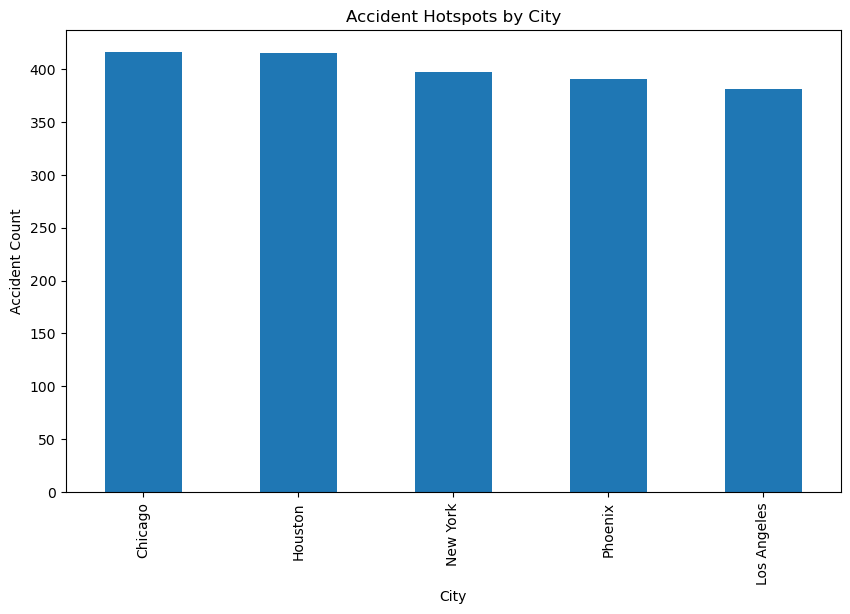

In [37]:
plt.figure(figsize=(10,6))

df['City'].value_counts().plot(
    kind='bar'
)

plt.title('Accident Hotspots by City')
plt.xlabel('City')
plt.ylabel('Accident Count')

plt.show()

In [39]:
df['Severity'].value_counts()

Severity
4    415
2    414
5    401
1    385
3    385
Name: count, dtype: int64

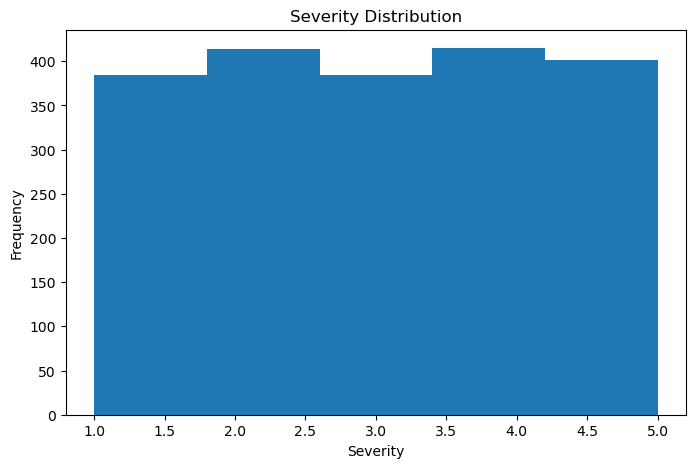

In [41]:
plt.figure(figsize=(8,5))

plt.hist(
    df['Severity'],
    bins=5
)

plt.title('Severity Distribution')
plt.xlabel('Severity')
plt.ylabel('Frequency')

plt.show()

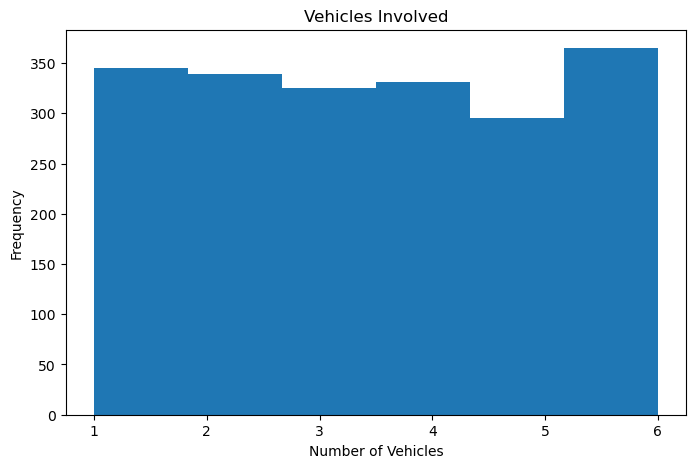

In [43]:
plt.figure(figsize=(8,5))

plt.hist(
    df['Vehicles_Involved'],
    bins=6
)

plt.title('Vehicles Involved')
plt.xlabel('Number of Vehicles')
plt.ylabel('Frequency')

plt.show()

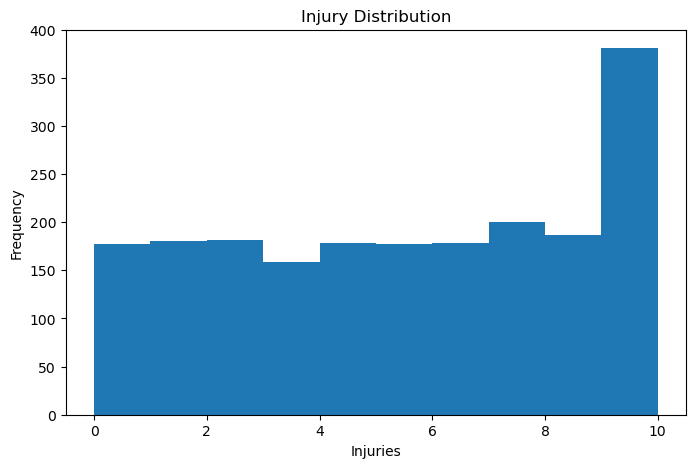

In [45]:
plt.figure(figsize=(8,5))

plt.hist(
    df['Injuries'],
    bins=10
)

plt.title('Injury Distribution')
plt.xlabel('Injuries')
plt.ylabel('Frequency')

plt.show()

In [47]:
df.groupby(
    'Weather'
)['Severity'].mean()

Weather
Clear     2.973333
Cloudy    3.066832
Fog       3.074359
Rain      3.012136
Snow      2.957041
Name: Severity, dtype: float64

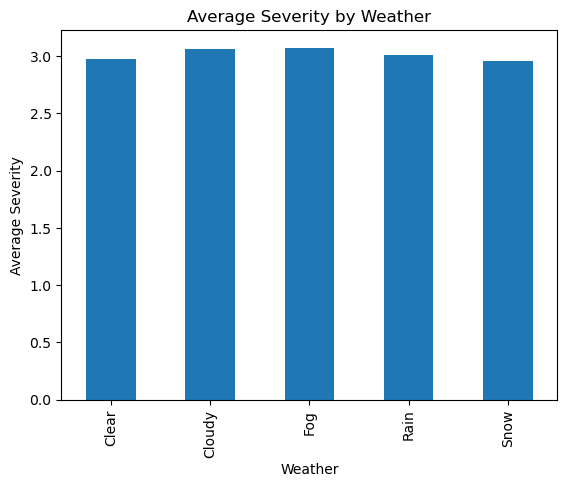

In [49]:
df.groupby(
    'Weather'
)['Severity'].mean().plot(
    kind='bar'
)

plt.title(
    'Average Severity by Weather'
)

plt.ylabel(
    'Average Severity'
)

plt.show()

In [51]:
df.groupby(
    'Road_Condition'
)['Injuries'].mean()

Road_Condition
Dry                   5.243299
Icy                   5.013699
Under Construction    5.015873
Wet                   5.164000
Name: Injuries, dtype: float64

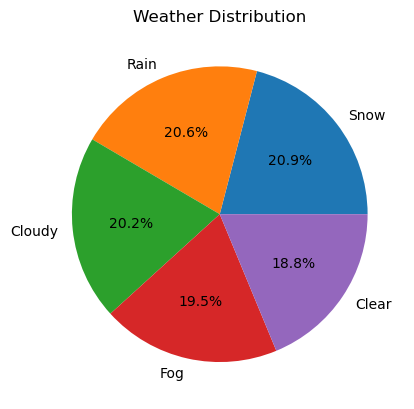

In [53]:
df['Weather'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title('Weather Distribution')
plt.ylabel('')

plt.show()

In [55]:
df.to_excel(
    'Traffic_Accident_Cleaned.xlsx',
    index=False
)

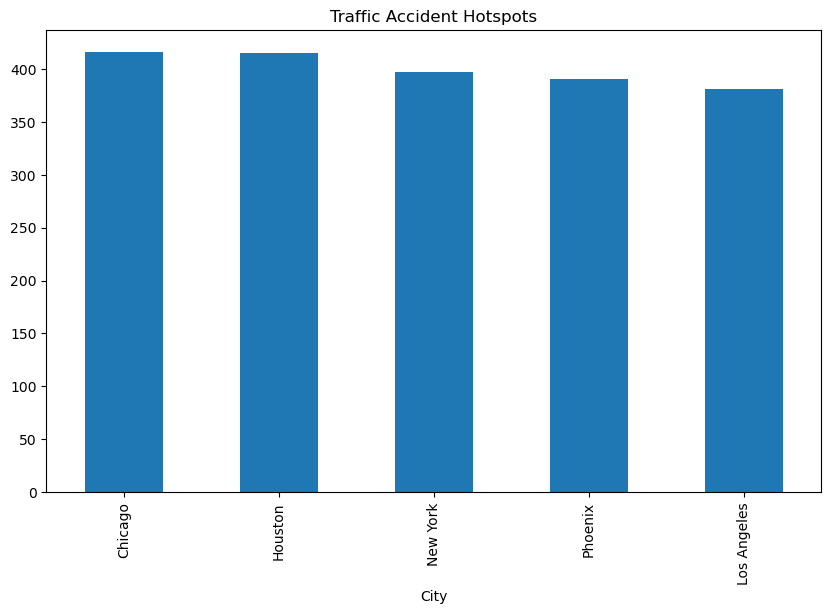

In [57]:
plt.figure(figsize=(10,6))

df['City'].value_counts().plot(
    kind='bar'
)

plt.title(
    'Traffic Accident Hotspots'
)

plt.savefig(
    'Traffic_Accident_Hotspots.png'
)

plt.show()

In [59]:
print("Total Accidents:", len(df))

print("\nWeather Conditions:")
print(df['Weather'].value_counts())

print("\nRoad Conditions:")
print(df['Road_Condition'].value_counts())

print("\nTime of Day:")
print(df['Time_of_Day'].value_counts())

Total Accidents: 2000

Weather Conditions:
Weather
Snow      419
Rain      412
Cloudy    404
Fog       390
Clear     375
Name: count, dtype: int64

Road Conditions:
Road_Condition
Icy                   511
Under Construction    504
Wet                   500
Dry                   485
Name: count, dtype: int64

Time of Day:
Time_of_Day
Morning      520
Night        504
Evening      498
Afternoon    478
Name: count, dtype: int64
